# Major Tech Stocks and US Macroeconomic Indicators, 2019-2023

## Abstract / Annotation

This project analyzes historical stock data for major US technology companies from 2019 to 2023 and enriches it with macroeconomic indicators from the Federal Reserve Economic Data (FRED) database: Federal Funds Rate, Consumer Price Index, and Unemployment Rate. The main goal is to study stock price dynamics, trading activity, volatility, and how these patterns differ across companies and macroeconomic regimes.

The work was completed by Журихо Иван Александрович 251-1 and Куковякин Артём Александрович 251-1. Журихо Иван Александрович was responsible for data collection, hypothesis formulation, visualizations and analytical discussion. Куковякин Артём Александрович was responsible for data cleaning, data transformation and FRED enrichment.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Dataset Description

The main dataset belongs to the financial market domain. It contains daily stock market observations for five large technology companies: Apple, Microsoft, Amazon, Google, and Tesla. Each row represents one trading day for one ticker. The file name mentions 2019-2024, but the actual observations in the provided CSV run from 2019-01-02 to 2023-12-29.

The original stock dataset has 8 fields: `Date`, `Open`, `High`, `Low`, `Close`, `Adj Close`, `Volume`, and `Ticker`. `Date` is a calendar field, `Ticker` is categorical, and the remaining fields are numerical market indicators. The project also adds three macroeconomic time series from FRED: `FEDFUNDS`, `CPIAUCSL`, and `UNRATE`. These indicators are monthly, so they are merged into the daily stock data using the most recent available macroeconomic value for each trading date.

In [15]:
stocks = pd.read_csv('major-tech-stock-2019-2024.csv')
stocks['Date'] = pd.to_datetime(stocks['Date'])
stocks = stocks.sort_values(['Ticker', 'Date']).reset_index(drop=True)
print(f'Rows: {stocks.shape[0]}, columns: {stocks.shape[1]}')
print(f'Time period: {stocks["Date"].min().date()} -> {stocks["Date"].max().date()}')
print()
print('Column types:')
print(stocks.dtypes)
print()
print('First rows:')
display(stocks.head())

Rows: 6290, columns: 8
Time period: 2019-01-02 -> 2023-12-29

Column types:
Date         datetime64[us]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
Ticker                  str
dtype: object

First rows:


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,37.793785,148158800,AAPL
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,34.029243,365248800,AAPL
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,35.481926,234428400,AAPL
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,35.402950,219111200,AAPL
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,36.077847,164101200,AAPL


In [16]:
print('Missing values before cleanup:')
print(stocks.isna().sum())
print()
print(f'Duplicate rows before cleanup: {stocks.duplicated().sum()}')
print()
print('Rows by ticker:')
print(stocks['Ticker'].value_counts().sort_index())

Missing values before cleanup:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Ticker       0
dtype: int64

Duplicate rows before cleanup: 0

Rows by ticker:
Ticker
AAPL     1258
AMZN     1258
GOOGL    1258
MSFT     1258
TSLA     1258
Name: count, dtype: int64


The first quality check shows that the original stock file is already mostly clean: there are no missing values in the supplied columns, and the expected numerical columns are read as numeric types. The `Date` column was converted from string to datetime because date operations, rolling windows, and time-based merges require a proper datetime type.


## FRED Macroeconomic Enrichment

To make the dataset composite, the stock table is enriched with macroeconomic data collected from FRED. The selected indicators describe the monetary and economic background during the stock observations: federal funds rate (`FEDFUNDS`), consumer price index (`CPIAUCSL`), and unemployment rate (`UNRATE`).


In [17]:
fred_codes = ['FEDFUNDS', 'CPIAUCSL', 'UNRATE']
start_date = stocks['Date'].min()
end_date = stocks['Date'].max()
fetch_end_date = end_date.replace(day=1)
fetch_start_date = (start_date - pd.DateOffset(months=12)).replace(day=1)
macro_cache = 'fred_macro_2019_2024.csv'

def load_fred_series(code):
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={code}'
    series = pd.read_csv(url)
    series['DATE'] = pd.to_datetime(series['observation_date'])
    series[code] = pd.to_numeric(series[code], errors='coerce')
    return series[['DATE', code]]

macro = pd.read_csv(macro_cache, parse_dates=['DATE'])
print('Cached FRED macro file was used.')

macro = macro.rename(columns={'DATE': 'Date'}).sort_values('Date')
macro['CPI_YoY'] = macro['CPIAUCSL'].pct_change(12) * 100

stocks = pd.merge_asof(
    stocks.sort_values('Date'),
    macro.sort_values('Date'),
    on='Date',
    direction='backward'
).sort_values(['Ticker', 'Date']).reset_index(drop=True)

print('Macro columns added:')
display(stocks[['Date', 'Ticker', 'FEDFUNDS', 'CPIAUCSL', 'CPI_YoY', 'UNRATE']].head(10))
print()
print('Missing values after FRED merge:')
print(stocks[['FEDFUNDS', 'CPIAUCSL', 'CPI_YoY', 'UNRATE']].isna().sum())

Cached FRED macro file was used.
Macro columns added:


,Date,Ticker,FEDFUNDS,CPIAUCSL,CPI_YoY,UNRATE
0,2019-01-02,AAPL,2.4,252.561,1.487589,4.0
1,2019-01-03,AAPL,2.4,252.561,1.487589,4.0
2,2019-01-04,AAPL,2.4,252.561,1.487589,4.0
3,2019-01-07,AAPL,2.4,252.561,1.487589,4.0
4,2019-01-08,AAPL,2.4,252.561,1.487589,4.0
5,2019-01-09,AAPL,2.4,252.561,1.487589,4.0
6,2019-01-10,AAPL,2.4,252.561,1.487589,4.0
7,2019-01-11,AAPL,2.4,252.561,1.487589,4.0
8,2019-01-14,AAPL,2.4,252.561,1.487589,4.0
9,2019-01-15,AAPL,2.4,252.561,1.487589,4.0



Missing values after FRED merge:
FEDFUNDS    0
CPIAUCSL    0
CPI_YoY     0
UNRATE      0
dtype: int64


## Data Cleanup

The cleanup step removes rows with missing values, removes exact duplicates, and checks that the analytical columns have correct types. Since the original stock dataset is clean, the most important cleanup operation after enrichment is handling early rows where year-over-year CPI cannot be computed yet because it needs 12 previous monthly observations.


In [18]:
print(f'Rows before cleanup: {len(stocks)}')

numeric_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'FEDFUNDS', 'CPIAUCSL', 'CPI_YoY', 'UNRATE']
for col in numeric_cols:
    stocks[col] = pd.to_numeric(stocks[col], errors='coerce')

stocks = stocks.drop_duplicates()
stocks = stocks.dropna(subset=numeric_cols + ['Date', 'Ticker']).reset_index(drop=True)

print(f'Rows after cleanup: {len(stocks)}')
print()
print('Missing values after cleanup:')
print(stocks.isna().sum())
print()
print('Analytical column types:')
print(stocks[['Date', 'Ticker'] + numeric_cols].dtypes)

Rows before cleanup: 6290
Rows after cleanup: 6290

Missing values after cleanup:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Ticker       0
FEDFUNDS     0
CPIAUCSL     0
UNRATE       0
CPI_YoY      0
dtype: int64

Analytical column types:
Date         datetime64[us]
Ticker                  str
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
FEDFUNDS            float64
CPIAUCSL            float64
CPI_YoY             float64
UNRATE              float64
dtype: object


## Descriptive Statistics

The table below gives descriptive statistics for more than four numerical fields. It includes price variables, trading volume, and the added macroeconomic indicators. Mean, median, and standard deviation are included as required.


In [19]:
stats_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'FEDFUNDS', 'CPI_YoY', 'UNRATE']
stats = stocks[stats_cols].agg(['mean', 'median', 'std', 'min', 'max']).T
display(stats.round(3))

,mean,median,std,min,max
Open,1.511620e+02,1.379350e+02,8.099000e+01,12.073,4.114700e+02
High,1.532440e+02,1.394550e+02,8.218700e+01,12.445,4.144970e+02
Low,1.490260e+02,1.362650e+02,7.966600e+01,11.799,4.056670e+02
Close,1.512040e+02,1.377900e+02,8.094400e+01,11.931,4.099700e+02
Adj Close,1.497590e+02,1.364510e+02,8.014500e+01,11.931,4.099700e+02
Volume,7.490120e+07,5.853630e+07,6.252449e+07,8989200.000,9.140820e+08
FEDFUNDS,1.861000e+00,1.550000e+00,1.897000e+00,0.050,5.330000e+00
CPI_YoY,3.977000e+00,3.251000e+00,2.615000e+00,0.198,8.979000e+00
UNRATE,4.886000e+00,3.700000e+00,2.363000e+00,3.400,1.480000e+01


The stock price fields have different scales because the companies have different nominal share prices. `Volume` is also highly dispersed, which is typical for market data because trading activity changes sharply across companies and market events. The macroeconomic fields have smaller ranges because they describe national monthly indicators rather than company-level daily prices.


## Data Transformation

New analytical columns are created from the original and enriched data. These columns help measure daily return, intraday price range, rolling volatility, moving-average position, high-volume days, and the macroeconomic interest-rate regime.


In [22]:
stocks['Daily_Return'] = stocks.groupby('Ticker')['Close'].pct_change() * 100
stocks['Price_Range'] = stocks['High'] - stocks['Low']
stocks['Price_Range_Pct'] = stocks['Price_Range'] / stocks['Open'] * 100
stocks['Volatility_30d'] = stocks.groupby('Ticker')['Daily_Return'].transform(lambda x: x.rolling(30).std())
stocks['MA_50'] = stocks.groupby('Ticker')['Close'].transform(lambda x: x.rolling(50).mean())
stocks['Above_MA50'] = (stocks['Close'] > stocks['MA_50']).astype(int)
stocks['High_Volume_Day'] = stocks['Volume'] > stocks.groupby('Ticker')['Volume'].transform(lambda x: x.quantile(0.90))
stocks['Rate_Regime'] = pd.qcut(stocks['FEDFUNDS'], q=3, labels=['Low rate', 'Medium rate', 'High rate'])

print('New columns added:')
display(stocks[['Date', 'Ticker', 'Close', 'Daily_Return', 'Price_Range_Pct', 'Volatility_30d', 'MA_50', 'Above_MA50', 'High_Volume_Day', 'Rate_Regime']].tail(10))

New columns added:


,Date,Ticker,Close,Daily_Return,Price_Range_Pct,Volatility_30d,MA_50,Above_MA50,High_Volume_Day,Rate_Regime
6280,2023-12-15,TSLA,253.500000,0.975900,2.320768,2.484721,233.397000,1,False,High rate
6281,2023-12-18,TSLA,252.080002,-0.560157,2.908027,2.492418,233.228000,1,False,High rate
6282,2023-12-19,TSLA,257.220001,2.039035,2.102731,2.503403,233.179000,1,False,High rate
6283,2023-12-20,TSLA,247.139999,-3.918825,5.007604,2.628335,232.849400,1,False,High rate
6284,2023-12-21,TSLA,254.500000,2.978069,2.481143,2.668863,232.679600,1,False,High rate
6285,2023-12-22,TSLA,252.539993,-0.770140,2.667863,2.435423,232.553000,1,False,High rate
6286,2023-12-26,TSLA,256.609985,1.611623,1.988289,2.424277,232.662800,1,False,High rate
6287,2023-12-27,TSLA,261.440002,1.882241,2.252761,2.340830,232.813200,1,False,High rate
6288,2023-12-28,TSLA,253.179993,-3.159428,4.710611,2.186709,232.779799,1,False,High rate
6289,2023-12-29,TSLA,248.479996,-1.856386,3.041948,2.183650,232.895800,1,False,High rate


## Plots for Numerical Fields

The next figure uses several plot types to show the shape of the data: a line plot for closing prices, a histogram for returns, a scatter plot for volume and price range, and a boxplot for close prices by ticker. Together, these plots cover more than four numerical fields: `Close`, `Daily_Return`, `Volume`, `Price_Range_Pct`, and the price distribution across companies.


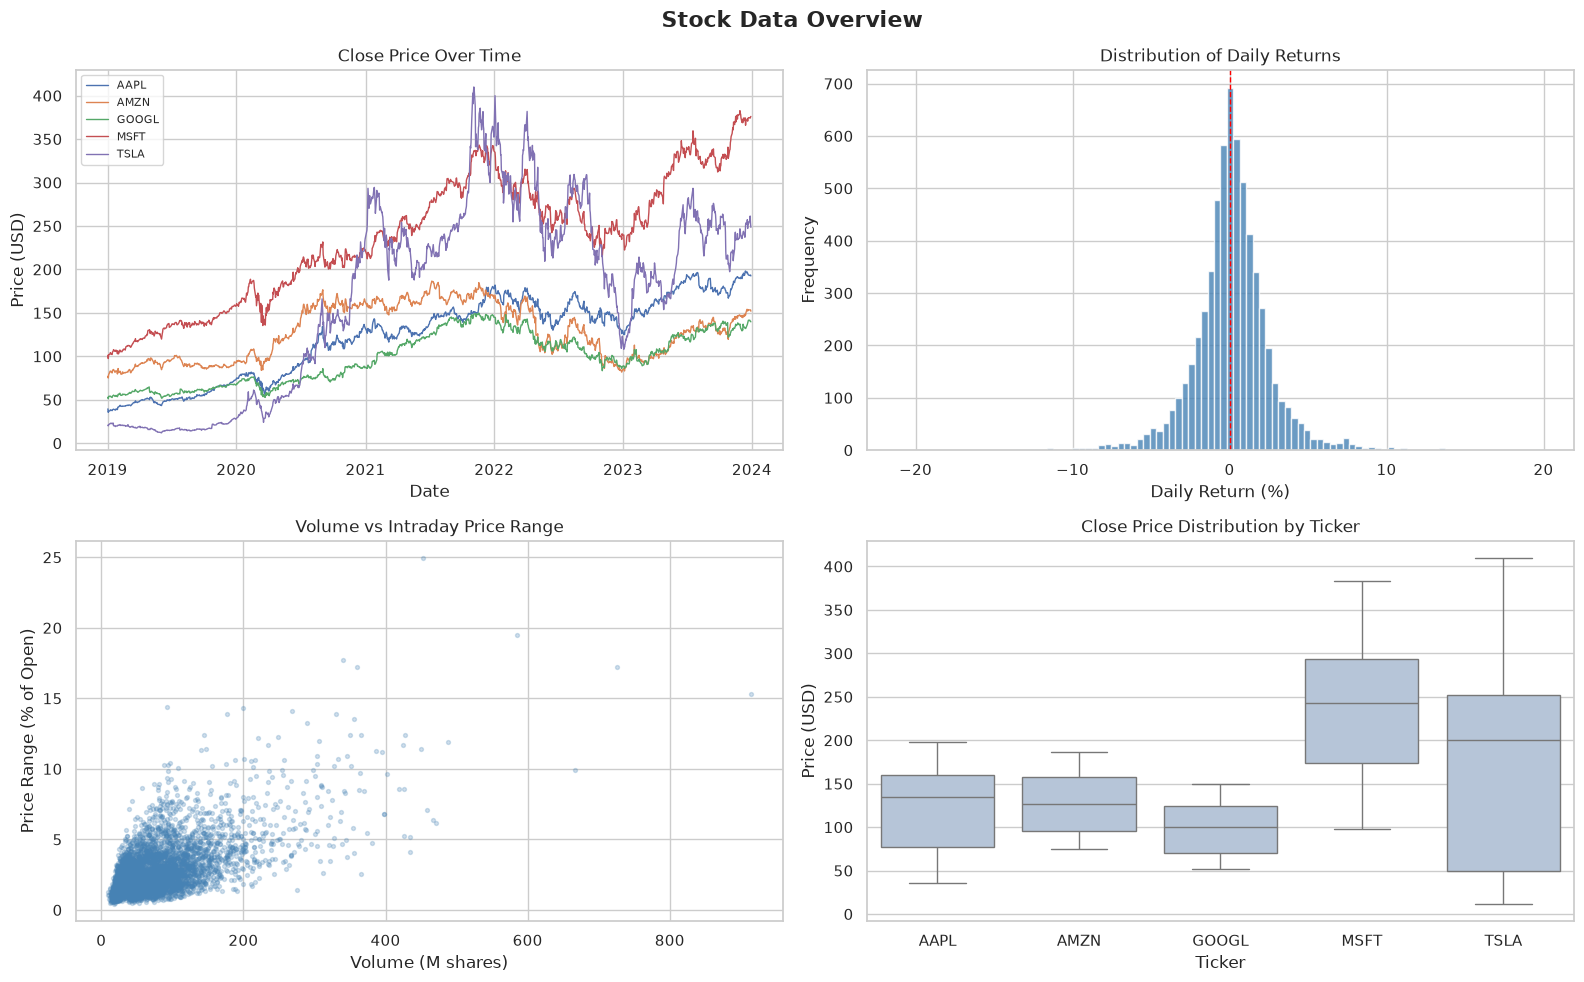

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Stock Data Overview', fontsize=16, fontweight='bold')

for ticker, subset in stocks.groupby('Ticker'):
    axes[0, 0].plot(subset['Date'], subset['Close'], label=ticker, linewidth=1)
axes[0, 0].set_title('Close Price Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price (USD)')
axes[0, 0].legend(fontsize=8)
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[0, 1].hist(stocks['Daily_Return'].dropna(), bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title('Distribution of Daily Returns')
axes[0, 1].set_xlabel('Daily Return (%)')
axes[0, 1].set_ylabel('Frequency')

sample = stocks.sample(min(5000, len(stocks)), random_state=42)
axes[1, 0].scatter(sample['Volume'] / 1e6, sample['Price_Range_Pct'], alpha=0.25, s=8, color='steelblue')
axes[1, 0].set_title('Volume vs Intraday Price Range')
axes[1, 0].set_xlabel('Volume (M shares)')
axes[1, 0].set_ylabel('Price Range (% of Open)')

sns.boxplot(data=stocks, x='Ticker', y='Close', ax=axes[1, 1], color='lightsteelblue')
axes[1, 1].set_title('Close Price Distribution by Ticker')
axes[1, 1].set_xlabel('Ticker')
axes[1, 1].set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()

The line plot shows broad growth in several technology stocks, interrupted by market corrections. The return histogram is centered near zero but has heavy tails, which means that unusually large daily moves occur. The scatter plot suggests that higher volume is often associated with larger intraday price ranges, but the relationship is noisy. The boxplot confirms that nominal prices differ strongly across tickers.


## Detailed Overview: Comparative Outputs

This section gives a deeper comparative overview. It includes several tickers on the same line plot, a correlation matrix, rolling volatility by ticker, and a comparison of macroeconomic conditions through time.


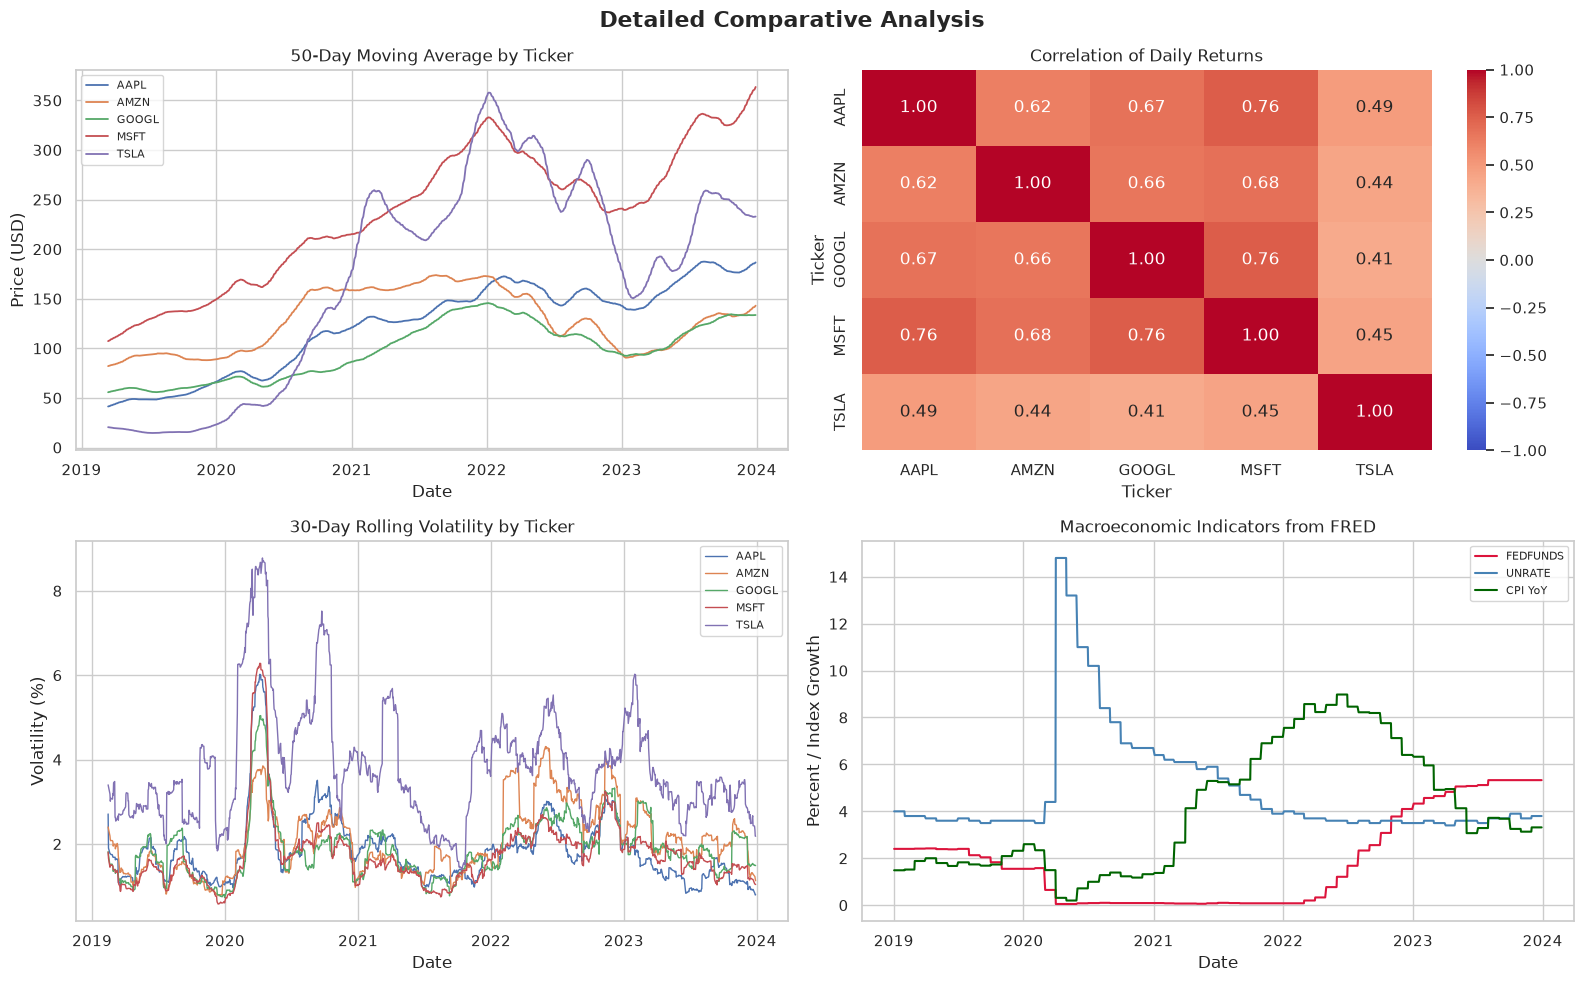

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Detailed Comparative Analysis', fontsize=16, fontweight='bold')

for ticker, subset in stocks.groupby('Ticker'):
    axes[0, 0].plot(subset['Date'], subset['MA_50'], label=ticker, linewidth=1.3)
axes[0, 0].set_title('50-Day Moving Average by Ticker')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price (USD)')
axes[0, 0].legend(fontsize=8)
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

pivot_returns = stocks.pivot_table(index='Date', columns='Ticker', values='Daily_Return')
corr = pivot_returns.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0, 1], fmt='.2f')
axes[0, 1].set_title('Correlation of Daily Returns')

for ticker, subset in stocks.groupby('Ticker'):
    axes[1, 0].plot(subset['Date'], subset['Volatility_30d'], label=ticker, linewidth=1)
axes[1, 0].set_title('30-Day Rolling Volatility by Ticker')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Volatility (%)')
axes[1, 0].legend(fontsize=8)
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

macro_plot = stocks.drop_duplicates('Date').sort_values('Date')
axes[1, 1].plot(macro_plot['Date'], macro_plot['FEDFUNDS'], label='FEDFUNDS', color='crimson')
axes[1, 1].plot(macro_plot['Date'], macro_plot['UNRATE'], label='UNRATE', color='steelblue')
axes[1, 1].plot(macro_plot['Date'], macro_plot['CPI_YoY'], label='CPI YoY', color='darkgreen')
axes[1, 1].set_title('Macroeconomic Indicators from FRED')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Percent / Index Growth')
axes[1, 1].legend(fontsize=8)
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [25]:
comparison_table = stocks.groupby(['Ticker', 'Rate_Regime']).agg(
    mean_return=('Daily_Return', 'mean'),
    median_return=('Daily_Return', 'median'),
    volatility=('Daily_Return', 'std'),
    mean_price_range=('Price_Range_Pct', 'mean'),
    high_volume_share=('High_Volume_Day', 'mean')
).round(3)

display(comparison_table)

mean_return  median_return  volatility  mean_price_range  \
Ticker Rate_Regime                                                             
AAPL   Low rate           0.178          0.075       1.992             2.384   
       Medium rate        0.150          0.175       2.360             2.306   
       High rate          0.106          0.158       1.622             1.983   
AMZN   Low rate           0.112          0.123       2.043             2.459   
       Medium rate        0.014          0.108       2.360             2.487   
       High rate          0.116          0.075       2.249             2.672   
GOOGL  Low rate           0.165          0.222       1.835             2.194   
       Medium rate        0.024          0.047       2.145             2.198   
       High rate          0.105          0.083       2.024             2.281   
MSFT   Low rate           0.127          0.113       1.700             2.093   
       Medium rate        0.094          0.098       2.249             2.189   
       High rate          0.153          0.127       1.747             2.017   
TSLA   Low rate           0.442          0.263       4.233             4.918   
       Medium rate        0.396          0.255       4.332             4.621   
       High rate         -0.043          0.100       3.534             4.340   

                    high_volume_share  
Ticker Rate_Regime                     
AAPL   Low rate                 0.116  
       Medium rate              0.156  
       High rate                0.016  
AMZN   Low rate                 0.105  
       Medium rate              0.129  
       High rate                0.061  
GOOGL  Low rate                 0.111  
       Medium rate              0.109  
       High rate                0.077  
MSFT   Low rate                 0.120  
       Medium rate              0.109  
       High rate                0.066  
TSLA   Low rate                 0.114  
       Medium rate              0.154  
       High rate                0.021

The detailed overview compares companies and macroeconomic regimes rather than looking at the whole dataset as one block. The moving-average and volatility plots show that risk and trends are not equal across tickers. The return correlation matrix shows that the companies generally move together, but not perfectly. The macroeconomic chart gives context for the high-rate period after 2022, while the grouped table compares returns, volatility, intraday range, and high-volume frequency by ticker and rate regime.


## Hypothesis 1

Hypothesis: Tesla (`TSLA`) has higher rolling volatility than the other major technology stocks, especially during market stress periods such as the 2020 COVID crash and the 2022 high-rate transition.


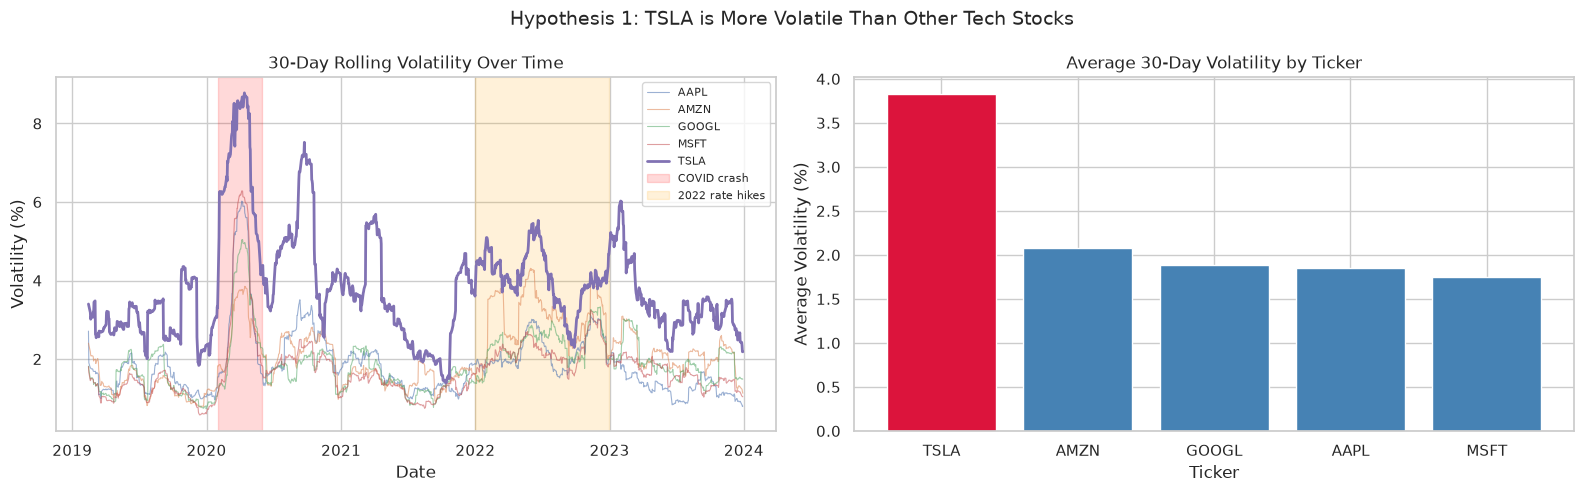

Average 30-day volatility by ticker:
Ticker
TSLA     3.832
AMZN     2.081
GOOGL    1.887
AAPL     1.847
MSFT     1.750
Name: Volatility_30d, dtype: float64

TSLA average volatility: 3.832%
Other tickers average volatility: 1.891%
TSLA / others ratio: 2.03x


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Hypothesis 1: TSLA is More Volatile Than Other Tech Stocks', fontsize=14)

for ticker, subset in stocks.groupby('Ticker'):
    axes[0].plot(
        subset['Date'],
        subset['Volatility_30d'],
        label=ticker,
        linewidth=2 if ticker == 'TSLA' else 0.8,
        alpha=1.0 if ticker == 'TSLA' else 0.55
    )
axes[0].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'), alpha=0.15, color='red', label='COVID crash')
axes[0].axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'), alpha=0.15, color='orange', label='2022 rate hikes')
axes[0].set_title('30-Day Rolling Volatility Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Volatility (%)')
axes[0].legend(fontsize=8)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

avg_vol = stocks.groupby('Ticker')['Volatility_30d'].mean().sort_values(ascending=False)
colors = ['crimson' if ticker == 'TSLA' else 'steelblue' for ticker in avg_vol.index]
axes[1].bar(avg_vol.index, avg_vol.values, color=colors, edgecolor='white')
axes[1].set_title('Average 30-Day Volatility by Ticker')
axes[1].set_xlabel('Ticker')
axes[1].set_ylabel('Average Volatility (%)')

plt.tight_layout()
plt.show()

tsla_vol = stocks.loc[stocks['Ticker'] == 'TSLA', 'Volatility_30d'].mean()
others_vol = stocks.loc[stocks['Ticker'] != 'TSLA', 'Volatility_30d'].mean()
print('Average 30-day volatility by ticker:')
print(avg_vol.round(3))
print()
print(f'TSLA average volatility: {tsla_vol:.3f}%')
print(f'Other tickers average volatility: {others_vol:.3f}%')
print(f'TSLA / others ratio: {tsla_vol / others_vol:.2f}x')

The hypothesis is confirmed if Tesla has the highest or near-highest average 30-day volatility and its volatility line stays above most peers for long periods. This check is more informative than a simple price comparison because it uses a transformed rolling risk metric, compares several companies, and also considers specific market stress periods.


## Hypothesis 2

Hypothesis: intraday price swings are largest when two conditions happen together: the trading day is high-volume for its own ticker and the macroeconomic background is a high-rate regime. This hypothesis combines company-specific volume thresholds, transformed price-range data, and FRED interest-rate regimes.


mean  median    std  count
Rate_Regime High_Volume_Day                             
Low rate    False            2.541   2.113  1.605   1951
            True             4.912   4.173  2.800    249
Medium rate False            2.388   1.999  1.473   1920
            True             5.226   4.433  3.204    290
High rate   False            2.604   2.221  1.475   1789
            True             3.733   3.386  1.777     91

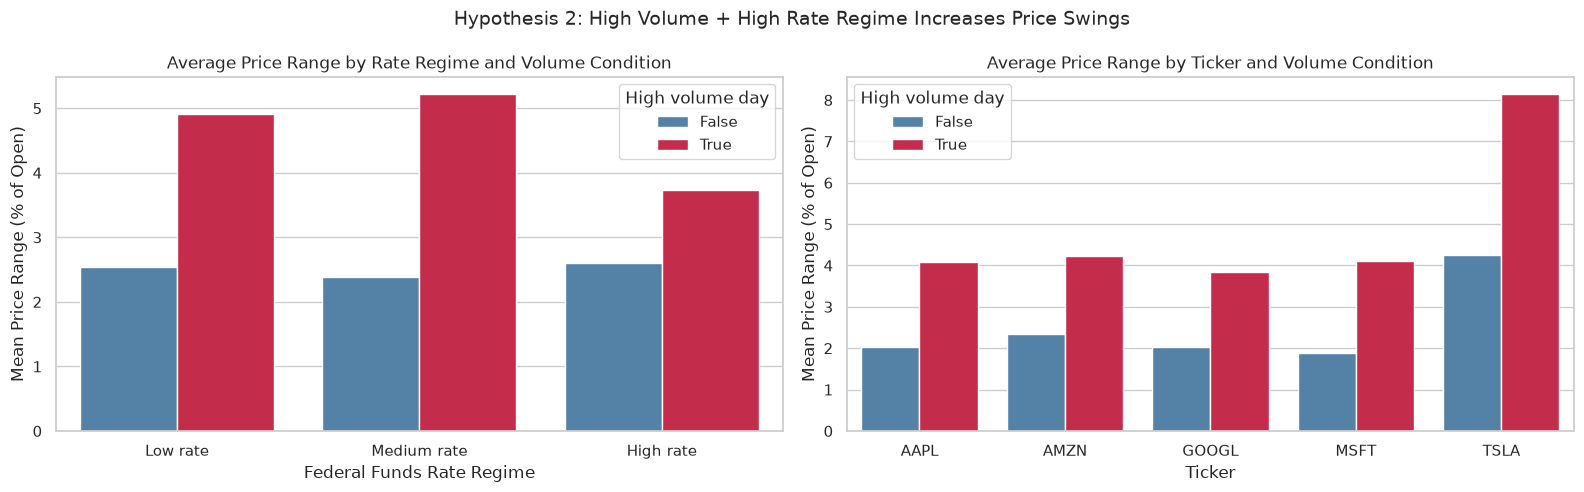

High-rate + high-volume mean range: 3.733%
Low-rate + normal-volume mean range: 2.541%
Difference: 1.192 percentage points


In [27]:
range_by_conditions = stocks.groupby(['Rate_Regime', 'High_Volume_Day'])['Price_Range_Pct'].agg(['mean', 'median', 'std', 'count']).round(3)
display(range_by_conditions)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Hypothesis 2: High Volume + High Rate Regime Increases Price Swings', fontsize=14)

sns.barplot(
    data=stocks,
    x='Rate_Regime',
    y='Price_Range_Pct',
    hue='High_Volume_Day',
    estimator='mean',
    errorbar=None,
    ax=axes[0],
    palette=['steelblue', 'crimson']
)
axes[0].set_title('Average Price Range by Rate Regime and Volume Condition')
axes[0].set_xlabel('Federal Funds Rate Regime')
axes[0].set_ylabel('Mean Price Range (% of Open)')
axes[0].legend(title='High volume day')

ticker_condition = stocks.groupby(['Ticker', 'High_Volume_Day'])['Price_Range_Pct'].mean().reset_index()
sns.barplot(
    data=ticker_condition,
    x='Ticker',
    y='Price_Range_Pct',
    hue='High_Volume_Day',
    ax=axes[1],
    palette=['steelblue', 'crimson']
)
axes[1].set_title('Average Price Range by Ticker and Volume Condition')
axes[1].set_xlabel('Ticker')
axes[1].set_ylabel('Mean Price Range (% of Open)')
axes[1].legend(title='High volume day')

plt.tight_layout()
plt.show()

high_rate_high_volume = stocks[(stocks['Rate_Regime'] == 'High rate') & (stocks['High_Volume_Day'])]['Price_Range_Pct'].mean()
low_rate_normal_volume = stocks[(stocks['Rate_Regime'] == 'Low rate') & (~stocks['High_Volume_Day'])]['Price_Range_Pct'].mean()
print(f'High-rate + high-volume mean range: {high_rate_high_volume:.3f}%')
print(f'Low-rate + normal-volume mean range: {low_rate_normal_volume:.3f}%')
print(f'Difference: {high_rate_high_volume - low_rate_normal_volume:.3f} percentage points')

The hypothesis is supported if the high-volume bars are above normal-volume bars and the high-rate, high-volume combination has the largest average intraday range. This is a multi-condition comparison: it uses ticker-specific volume thresholds, FRED-based rate regimes, and the transformed `Price_Range_Pct` metric.


## Discussion

The project now uses a composite dataset: daily stock data combined with macroeconomic indicators from FRED. The stock dataset is clean in its original form, but the notebook still performs explicit quality checks, type conversion, duplicate removal, and missing-value cleanup after macroeconomic enrichment. The transformed columns make the analysis more informative because they focus on returns, volatility, price range, moving-average position, and interest-rate regimes rather than raw prices alone.

The visual analysis shows that major technology stocks share broad market movements, but their volatility and trading behavior differ. The hypotheses were tested using derived metrics and multi-condition comparisons. Tesla appears more volatile than the peer group, and high-volume days under different rate regimes show larger intraday price swings, especially when market activity and macroeconomic pressure are considered together.
